<a href="https://colab.research.google.com/github/news-trackers/spark-nlp-workspace/blob/main/tutorials/logging/MLFlow_NER_template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

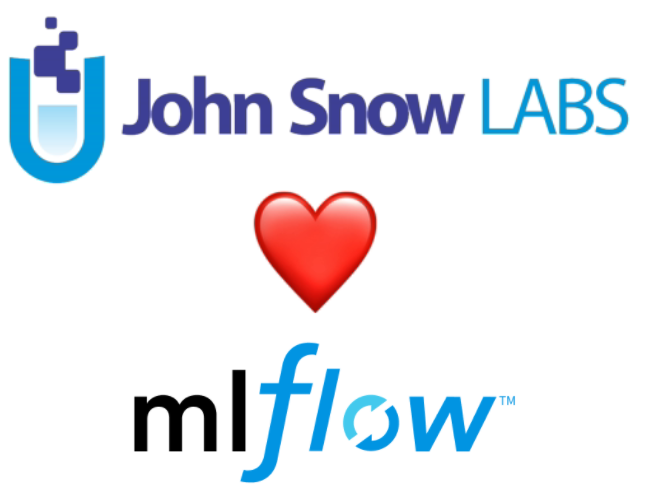

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/spark-nlp-workshop/blob/master/tutorials/logging/MLFLow_NER_template.ipynb)

[MLFlow](https://www.mlflow.org/) MLflow is an open source platform to manage the ML lifecycle, including experimentation, reproducibility, deployment, and a central model registry. MLFlow supports natively Spark MLLib and Spark NLP Pipelines, among many other formats (flavours), and runs transparently in Databricks.

# Installation

In [ ]:
! wget -q http://setup.johnsnowlabs.com/colab.sh -O - | bash

In [2]:
!pip install mlflow==3.15.1

# Imports

In [3]:
import json
import os
from sklearn.metrics import classification_report
import time
import mlflow
from mlflow.models.signature import infer_signature
from urllib.parse import urlparse
import pandas as pd
import glob

In [4]:
import sparknlp
from sparknlp.base import *
from sparknlp.annotator import *
from sparknlp.training import *
from pyspark.ml import Pipeline
import pyspark.sql.functions as F
from sparknlp.training import CoNLL
from pyspark.sql import SparkSession

### Check sparknlp and mlflow versions

In [5]:
sparknlp.version()

'6.4.2'

In [6]:
mlflow.__version__

'3.15.1'

### Add mysql connection string to mlflow

In [29]:
mlflow.set_tracking_uri("http://46.249.102.86:5065")
mlflow.get_tracking_uri()

'http://46.249.102.86:5065'

### We create a const var with them, to pass them later on to MLFLow

In [7]:
PIP_REQUIREMENTS = [f"sparknlp=={sparknlp.version()}", f"mlflow=={mlflow.__version__}"]
PIP_REQUIREMENTS

['sparknlp==6.4.2', 'mlflow==3.15.1']

In [56]:
%%writefile ner_image_log_parser.py
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def parse_logfile(path):
    with open(path, "r") as f:
        log = f.read()

    data = []
    current_epoch = None
    set_idx = None
    for line in log.split("\n"):
        row = re.findall(r"\S+", line)

        if row and row[0]=="Epoch":
            current_epoch = int(row[1].split('/')[0])
        if row and row[0] == "set:" and row[1] == "train":
            set_idx = row[1]
        if row and row[0] == "set:" and row[1] == "test":
            set_idx = row[1]
        # Handle B- and I- entity metrics
        if row and row[0][:2] in ["B-","I-"]:
            # Extract precision, recall, f1 from specific indices, assuming 'prec:', 'rec:', 'f1:' tokens
            precision = float(row[2].replace(',', ''))
            recall = float(row[4].replace(',', ''))
            f1 = float(row[6].replace(',', ''))
            data.append((current_epoch, set_idx, row[0], row[0].split("-")[-1], precision, recall, f1))
        # Handle Macro-average metrics
        if row and row[0][:13]=="Macro-average":
            # Extract precision, recall, f1 from specific indices
            precision = float(row[2].replace(',', ''))
            recall = float(row[4].replace(',', ''))
            f1 = float(row[6].replace(',', ''))
            data.append((current_epoch, set_idx, row[0], row[0], precision, recall, f1))
        # Handle Micro-average metrics
        if row and row[0][:13]=="Micro-average":
            # Extract precision, recall, f1 from specific indices
            precision = float(row[2].replace(',', ''))
            recall = float(row[4].replace(',', ''))
            f1 = float(row[6].replace(',', ''))
            data.append((current_epoch, set_idx, row[0], row[0], precision, recall, f1))

    metrics = pd.DataFrame(data, columns=["epoch", "set", "ner_label", "entity", "precision", "recall", "f1"])
    return metrics[metrics.ner_label.isin(["Micro-average", "Macro-average"])==False], \
        metrics[metrics.ner_label.isin(["Micro-average", "Macro-average"])], \
        metrics[metrics.ner_label.isin(["Micro-average", "Macro-average"])==False][["epoch", "set", "entity"]].drop_duplicates()

def aggregate_entities(metrics_df):
    chart_metrics = metrics_df.groupby(["epoch", "set", "entity"]).mean().reset_index()
    chart_metrics = chart_metrics.rename(columns={"precision": "Precision", "recall": "Recall", "f1": "F1"})
    return chart_metrics

def get_charts(log_file, threshold=0, img_prec_rec_f1_path="precision_recall_f1.jpg", img_macro_micro_avg_path="macro_micro_avg.jpg"):

    images = {}
    metrics, avg_metrics, graph = parse_logfile(log_file)

    chart_metrics = aggregate_entities(metrics)
    for metric in ["Precision", "Recall", "F1"]:
        plt.figure(figsize=(15,5))
        for ent in graph.entity.unique():
            plt.plot(chart_metrics[(chart_metrics.set=="test") & (chart_metrics.entity == ent)]["epoch"], \
                    chart_metrics[(chart_metrics.set=="test") & (chart_metrics.entity == ent)][metric], \
                    label = ent)
            plt.plot(chart_metrics[(chart_metrics.set=="train") & (chart_metrics.entity == ent)]["epoch"], \
                    chart_metrics[(chart_metrics.set=="train") & (chart_metrics.entity == ent)][metric], \
                    label = ent, linestyle='dashed')

        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title("Spark NLP NERDL %s for Each Entity" %metric)
        plt.savefig(f'{img_prec_rec_f1_path.replace(".jpg", "-")+metric}.jpg')
        images[f'{img_prec_rec_f1_path.replace(".jpg", "-")+metric}.jpg'] = plt.gcf()

    avg_metrics = avg_metrics.rename(columns={"precision": "Precision", "recall": "Recall", "f1": "F1"})
    for metric in ["Precision", "Recall", "F1"]:
        plt.figure(figsize=(15,5))
        for ent in avg_metrics.ner_label.unique():
            plt.plot(avg_metrics[(avg_metrics.set=="test") & (avg_metrics.ner_label == ent)]["epoch"], \
                    avg_metrics[(avg_metrics.set=="test") & (avg_metrics.ner_label == ent)][metric], \
                    label = ent)
            plt.plot(avg_metrics[(avg_metrics.set=="train") & (avg_metrics.ner_label == ent)]["epoch"], \
                    avg_metrics[(avg_metrics.set=="train") & (avg_metrics.ner_label == ent)][metric], \
                    label = ent, linestyle='dashed')

        plt.xlabel("Epoch")
        plt.ylabel(metric)
        plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
        plt.title("Spark NLP NERDL %s for Micro/Macro Averages" %metric)
        plt.savefig(f'{img_macro_micro_avg_path.replace(".jpg", "-")+metric}.jpg')
        images[f'{img_macro_micro_avg_path.replace(".jpg", "-")+metric}.jpg'] = plt.gcf()

    return images

def loss_plot(log_file, img_loss_path="loss.jpg"):
    with open(log_file, 'r') as f:
        log_content = f.read()

    loss_values = []
    for line in log_content.splitlines():
        match = re.search(r'loss: (\d+\.\d+)', line)
        if match:
            loss_values.append(float(match.group(1)))

    plt.figure(figsize=(15, 5))
    plt.plot(loss_values)
    plt.title('Loss Plot')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.savefig(img_loss_path)
    return {img_loss_path: plt.gcf()}

Overwriting ner_image_log_parser.py


In [8]:
import ner_image_log_parser

## Starting a Spark Session for SparkNLP

In [10]:
def start():
    spark_nlp_version = sparknlp.version()
    builder = SparkSession.builder \
        .appName("Spark NLP") \
        .master("local[*]") \
        .config("spark.driver.memory", "256G") \
        .config("spark.serializer", "org.apache.spark.serializer.KryoSerializer") \
        .config("spark.kryoserializer.buffer.max", "2000M") \
        .config("spark.driver.maxResultSize","4000M") \
        .config("spark.jars.packages", f"com.johnsnowlabs.nlp:spark-nlp_2.12:{spark_nlp_version},org.mlflow:mlflow-spark:1.21.0")

    return builder.getOrCreate()

spark = start()

In [11]:
spark

# Preparing the NERDLApproach() model training

## Data preparation

In [12]:
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp/master/src/test/resources/conll2003/eng.train
!wget -q https://raw.githubusercontent.com/JohnSnowLabs/spark-nlp/master/src/test/resources/conll2003/eng.testa

In [13]:
TRAIN_DATASET = "eng.train"
TEST_DATASET = "eng.testa"

In [14]:
with open(TRAIN_DATASET) as f:
    train_txt =f.read()

print (train_txt[:500])

-DOCSTART- -X- -X- O

EU NNP B-NP B-ORG
rejects VBZ B-VP O
German JJ B-NP B-MISC
call NN I-NP O
to TO B-VP O
boycott VB I-VP O
British JJ B-NP B-MISC
lamb NN I-NP O
. . O O

Peter NNP B-NP B-PER
Blackburn NNP I-NP I-PER

BRUSSELS NNP B-NP B-LOC
1996-08-22 CD I-NP O

The DT B-NP O
European NNP I-NP B-ORG
Commission NNP I-NP I-ORG
said VBD B-VP O
on IN B-PP O
Thursday NNP B-NP O
it PRP B-NP O
disagreed VBD B-VP O
with IN B-PP O
German JJ B-NP B-MISC
advice NN I-NP O
to TO B-PP O
consumers NNS B-NP


In [15]:
training_data = CoNLL().readDataset(spark, TRAIN_DATASET)
training_data.show(3)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|                text|            document|            sentence|               token|                 pos|               label|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
|EU rejects German...|[{document, 0, 47...|[{document, 0, 47...|[{token, 0, 1, EU...|[{pos, 0, 1, NNP,...|[{named_entity, 0...|
|     Peter Blackburn|[{document, 0, 14...|[{document, 0, 14...|[{token, 0, 4, Pe...|[{pos, 0, 4, NNP,...|[{named_entity, 0...|
| BRUSSELS 1996-08-22|[{document, 0, 18...|[{document, 0, 18...|[{token, 0, 7, BR...|[{pos, 0, 7, NNP,...|[{named_entity, 0...|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+
only showing top 3 rows



In [16]:
%%time
TRAINING_SIZE = training_data.count()
TRAINING_SIZE

CPU times: user 3.22 ms, sys: 62 µs, total: 3.28 ms
Wall time: 6.36 s


14041

In [17]:
training_data.printSchema()

root
 |-- text: string (nullable = true)
 |-- document: array (nullable = false)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: string (valueContainsNull = true)
 |    |    |-- embeddings: array (nullable = true)
 |    |    |    |-- element: float (containsNull = false)
 |-- sentence: array (nullable = false)
 |    |-- element: struct (containsNull = true)
 |    |    |-- annotatorType: string (nullable = true)
 |    |    |-- begin: integer (nullable = false)
 |    |    |-- end: integer (nullable = false)
 |    |    |-- result: string (nullable = true)
 |    |    |-- metadata: map (nullable = true)
 |    |    |    |-- key: string
 |    |    |    |-- value: string (valueContainsNull = tr

In [19]:
training_data.select(
    F.explode(
        F.arrays_zip(
            F.col('token.result').alias('token_res'),
            F.col('pos.result').alias('pos_res'),
            F.col('label.result').alias('label_res')
        )
    ).alias("cols")
) \
.select(
    F.col("cols.token_res").alias("token"),
    F.col("cols.pos_res").alias("pos"),
    F.col("cols.label_res").alias("ner_label")
).show(truncate=50)

+----------+---+---------+
|     token|pos|ner_label|
+----------+---+---------+
|        EU|NNP|    B-ORG|
|   rejects|VBZ|        O|
|    German| JJ|   B-MISC|
|      call| NN|        O|
|        to| TO|        O|
|   boycott| VB|        O|
|   British| JJ|   B-MISC|
|      lamb| NN|        O|
|         .|  .|        O|
|     Peter|NNP|    B-PER|
| Blackburn|NNP|    I-PER|
|  BRUSSELS|NNP|    B-LOC|
|1996-08-22| CD|        O|
|       The| DT|        O|
|  European|NNP|    B-ORG|
|Commission|NNP|    I-ORG|
|      said|VBD|        O|
|        on| IN|        O|
|  Thursday|NNP|        O|
|        it|PRP|        O|
+----------+---+---------+
only showing top 20 rows



In [21]:
training_data.select(
    F.explode(
        F.arrays_zip(
            F.col('token.result').alias('token_res'),
            F.col('label.result').alias('label_res')
        )
    ).alias("cols")
) \
.select(
    F.col("cols.token_res").alias("token"),
    F.col("cols.label_res").alias("ground_truth")
).groupBy('ground_truth').count().orderBy('count', ascending=False).show(100,truncate=False)

+------------+------+
|ground_truth|count |
+------------+------+
|O           |169578|
|B-LOC       |7140  |
|B-PER       |6600  |
|B-ORG       |6321  |
|I-PER       |4528  |
|I-ORG       |3704  |
|B-MISC      |3438  |
|I-LOC       |1157  |
|I-MISC      |1155  |
+------------+------+



## Hyperparameters preparation

In [22]:
MODEL_NAME = 'NER_base_2048_mlflow'
EXPERIMENT_NAME = "2048_BATCH_TEST_5" # Change me to reflect different experiments for same model
OUTPUT_DIR = f"{MODEL_NAME}_{EXPERIMENT_NAME}_output"
MODEL_DIR = f"model"

In [30]:
EXPERIMENT_ID = mlflow.create_experiment(f"{MODEL_NAME}_{EXPERIMENT_NAME}")

In [31]:
MAX_EPOCHS = 10
LEARNING_RATE = 0.003
BATCH_SIZE = 2048
RANDOM_SEED = 0
VALIDATION_SPLIT = 0.1

In [32]:
!mkdir $OUTPUT_DIR

## Pipeline preparation

In [33]:
document = DocumentAssembler()\
        .setInputCol("text")\
        .setOutputCol("document")

sentence = SentenceDetector()\
        .setInputCols(['document'])\
        .setOutputCol('sentence')

token = Tokenizer()\
        .setInputCols(['sentence'])\
        .setOutputCol('token')

embeddings = BertEmbeddings.pretrained("bert_base_cased", "en") \
      .setInputCols("sentence", "token") \
      .setOutputCol("embeddings")

ner_approach = NerDLApproach()\
      .setInputCols(["sentence", "token", "embeddings"])\
      .setLabelColumn("label")\
      .setOutputCol("ner")\
      .setMaxEpochs(MAX_EPOCHS)\
      .setLr(LEARNING_RATE)\
      .setBatchSize(BATCH_SIZE)\
      .setRandomSeed(RANDOM_SEED)\
      .setVerbose(1)\
      .setEnableOutputLogs(True)\
      .setIncludeConfidence(True)\
      .setIncludeAllConfidenceScores(True)\
      .setEvaluationLogExtended(True)\
      .setOutputLogsPath(OUTPUT_DIR)\
      .setValidationSplit(VALIDATION_SPLIT)

bert_base_cased download started this may take some time.
Approximate size to download 384.9 MB
[OK!]


In [34]:
ner_preprocessing_pipeline = Pipeline(stages=[
    document,
    sentence,
    token,
    embeddings
 ])

In [35]:
ner_training_pipeline = Pipeline(stages = ner_preprocessing_pipeline.getStages() + [ner_approach])

In [36]:
ner_preprocessing_pipeline.getStages()

[DocumentAssembler_dcb1ac57c8ae,
 SentenceDetector_2c88ec902432,
 Tokenizer_895906489566,
 BERT_EMBEDDINGS_74a68b8d2159]

In [37]:
ner_training_pipeline.getStages()

[DocumentAssembler_dcb1ac57c8ae,
 SentenceDetector_2c88ec902432,
 Tokenizer_895906489566,
 BERT_EMBEDDINGS_74a68b8d2159,
 NerDLApproach_919ec1e77336]

# Preparing the NERDLApproach() model inference

## Data preparation

In [38]:
test_data = CoNLL().readDataset(spark, TEST_DATASET)

In [39]:
%%time
TEST_SIZE = test_data.count()
TEST_SIZE

CPU times: user 1.54 ms, sys: 70 µs, total: 1.61 ms
Wall time: 1.43 s


3250

## Inference results and metrics filenames

In [40]:
INFERENCE_NAME = "inference.parquet"
CLASSIFICATION_REPORT_LOG_NAME = "classification_report.txt"

In [41]:
PREC_REC_F1_NAME = "precrecf1.jpg"
MACRO_MICRO_AVG_NAME = "macromicroavg.jpg"
LOSS_NAME = "loss.jpg"

In [42]:
# Comment this to production pursoses. Uncomment for testing.
training_data = training_data.limit(100)
test_data = test_data.limit(100)

# MLFlow experiment

Model name: NER_base_2048_mlflow
Run id: d2f51fe080ad4de8b885f572a078096f
Experiment id: 1
Starting training...
- Finished!
Saving the model...
- Finished!
Loading back the model...
Starting inference...
- Finished!
Starting metric calculation...


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

- Finished!
Training dataset size: 14041
Training time (sec): 48.53500056266785
Inference dataset size: 3250
Inference time (sec): 23.433799028396606
Metrics:

              precision    recall  f1-score   support

       B-LOC       0.31      0.62      0.42        58
      B-MISC       0.17      0.08      0.11        12
       B-ORG       0.47      0.11      0.18        70
       B-PER       0.73      0.19      0.30        58
       I-LOC       0.00      0.00      0.00        10
      I-MISC       0.00      0.00      0.00         5
       I-ORG       0.83      0.36      0.50        14
       I-PER       0.49      0.38      0.42        45
           O       0.90      0.97      0.94      1117

    accuracy                           0.83      1389
   macro avg       0.43      0.30      0.32      1389
weighted avg       0.82      0.83      0.81      1389

Logging params, artifacts, metrics and charts in MLFlow
- Finished!
Logging the model in MLFlow


Successfully registered model 'NER_base_2048_mlflow'.
2026/08/11 15:25:31 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: NER_base_2048_mlflow, version 1
Created version '1' of model 'NER_base_2048_mlflow'.


- Finished!
Saving the model...


2026/08/11 15:25:32 WARNING mlflow.spark: Failed to infer the model signature from the input example. Reason: ValueError('Some of types cannot be determined after inferring'). To see the full traceback, set the logging level to DEBUG via `logging.getLogger("mlflow").setLevel(logging.DEBUG)`.


- Finished!
🏃 View run wistful-mole-963 at: http://46.249.102.86:5065/#/experiments/1/runs/d2f51fe080ad4de8b885f572a078096f
🧪 View experiment at: http://46.249.102.86:5065/#/experiments/1


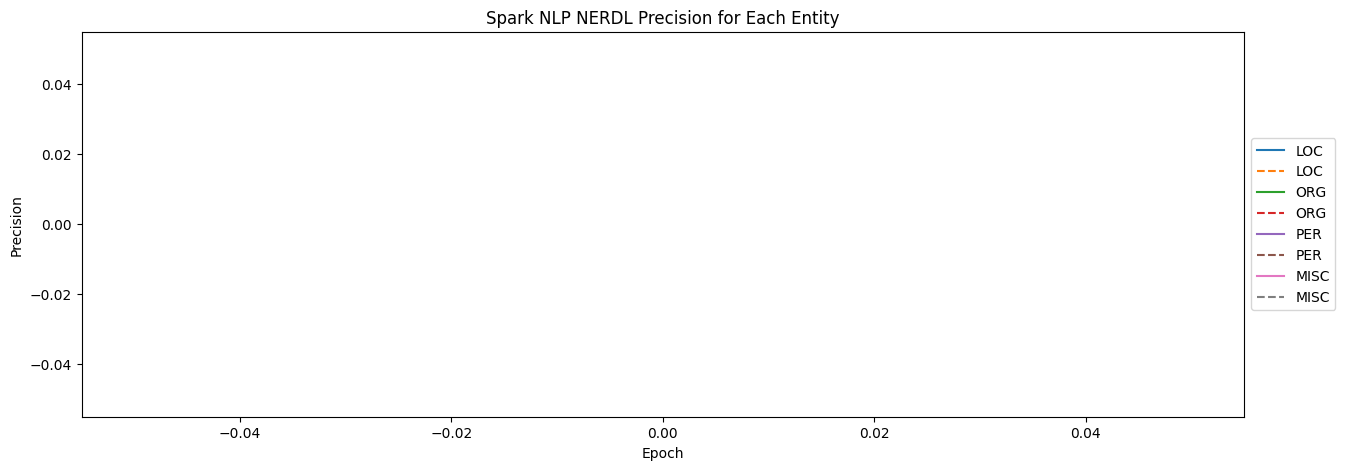

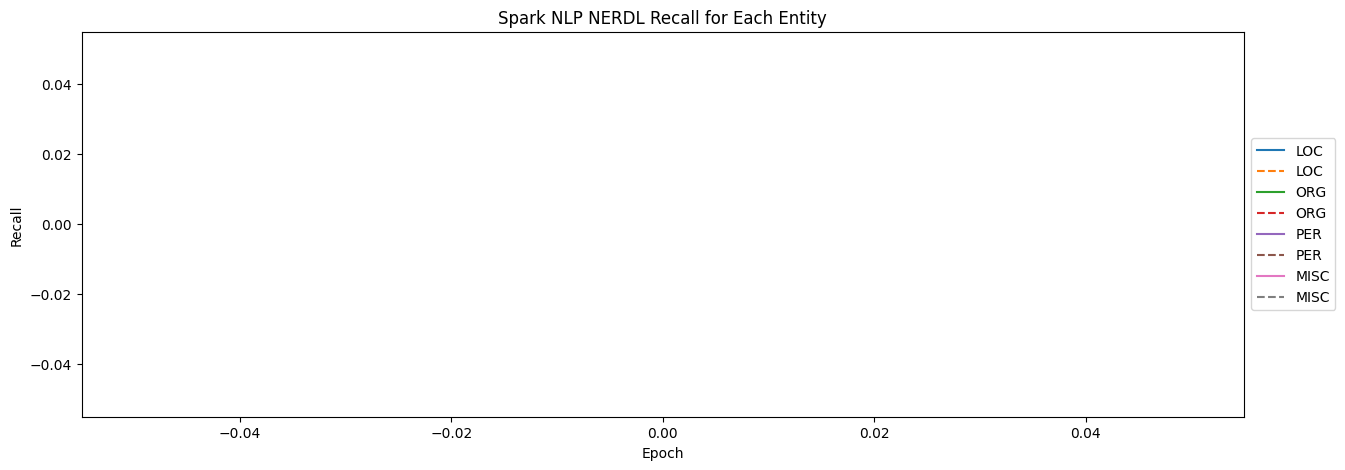

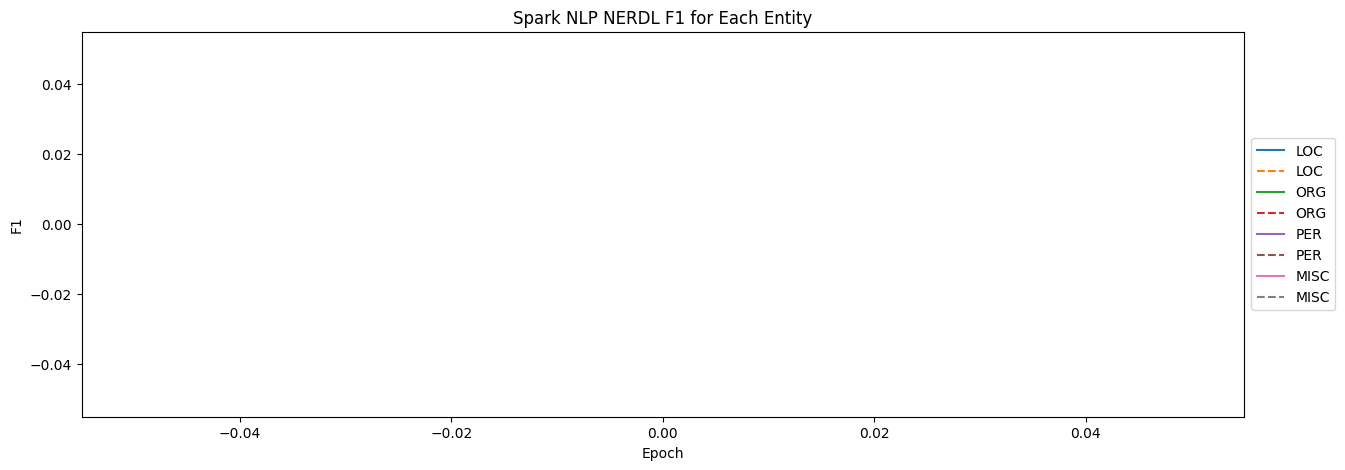

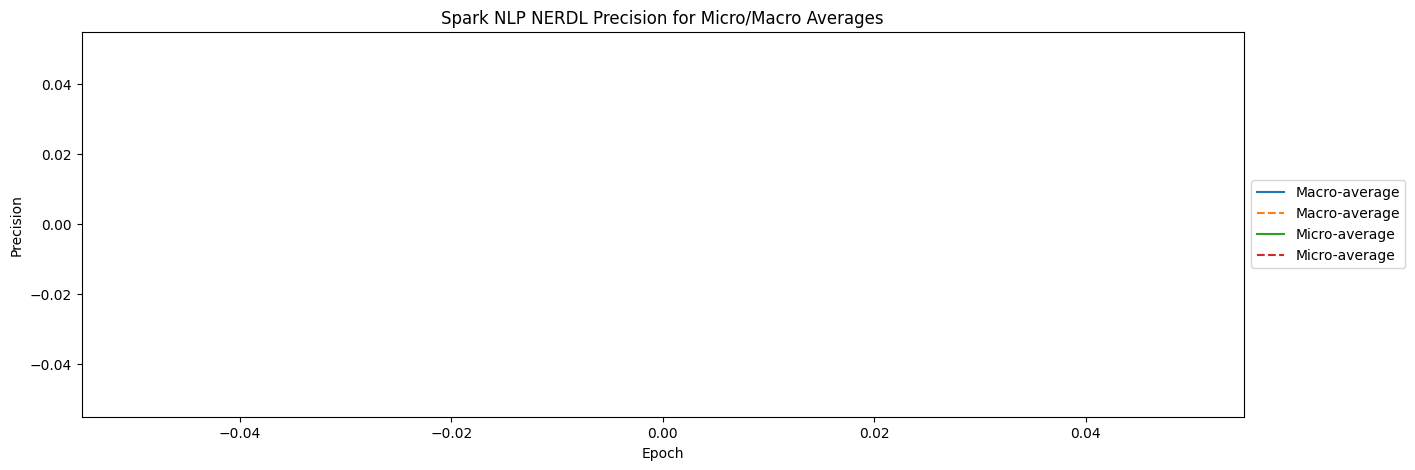

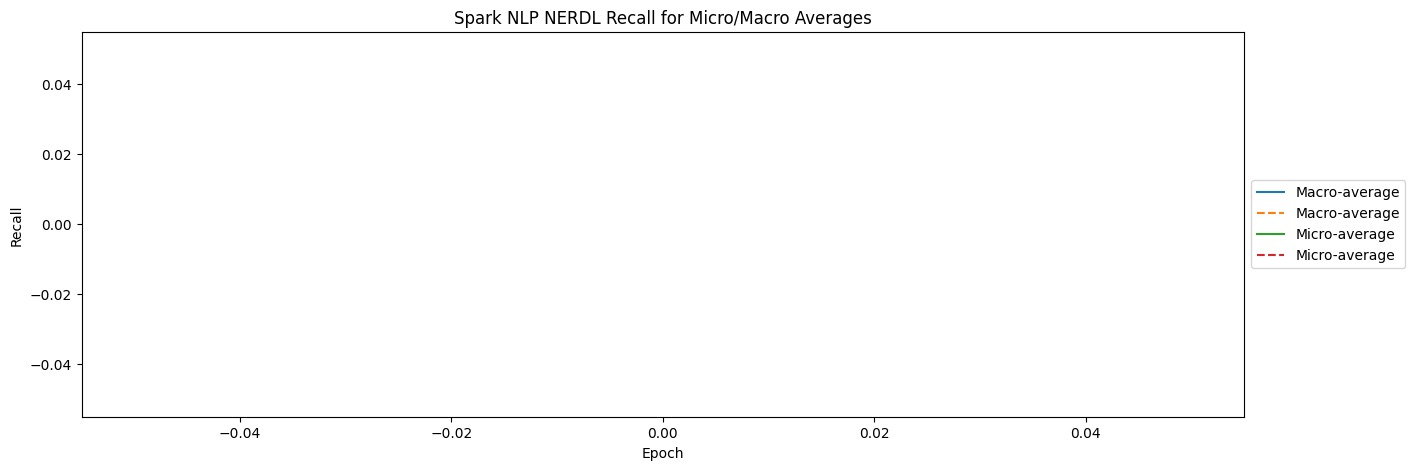

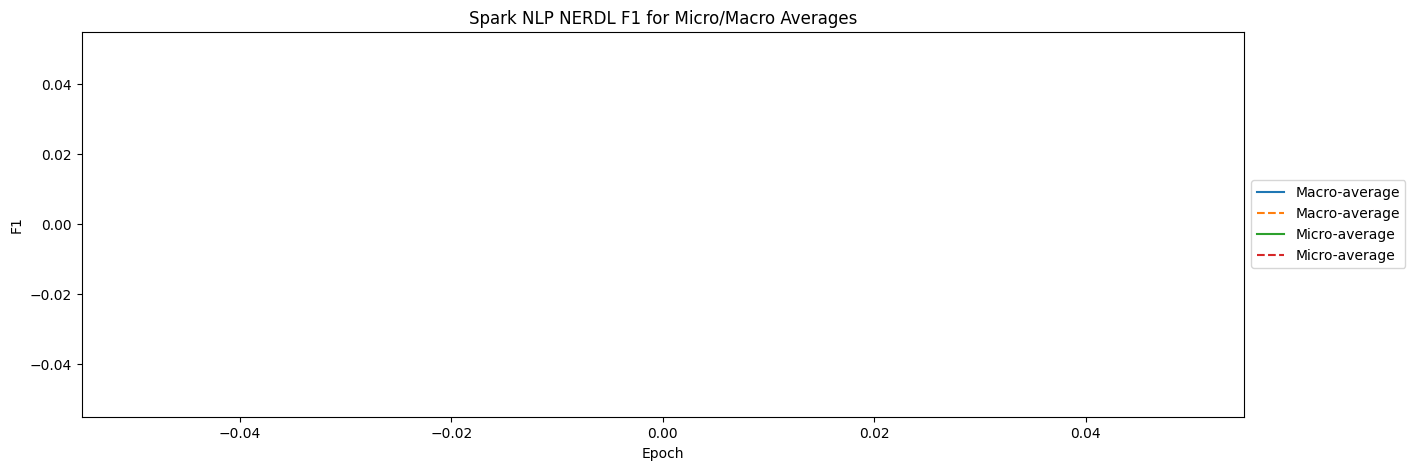

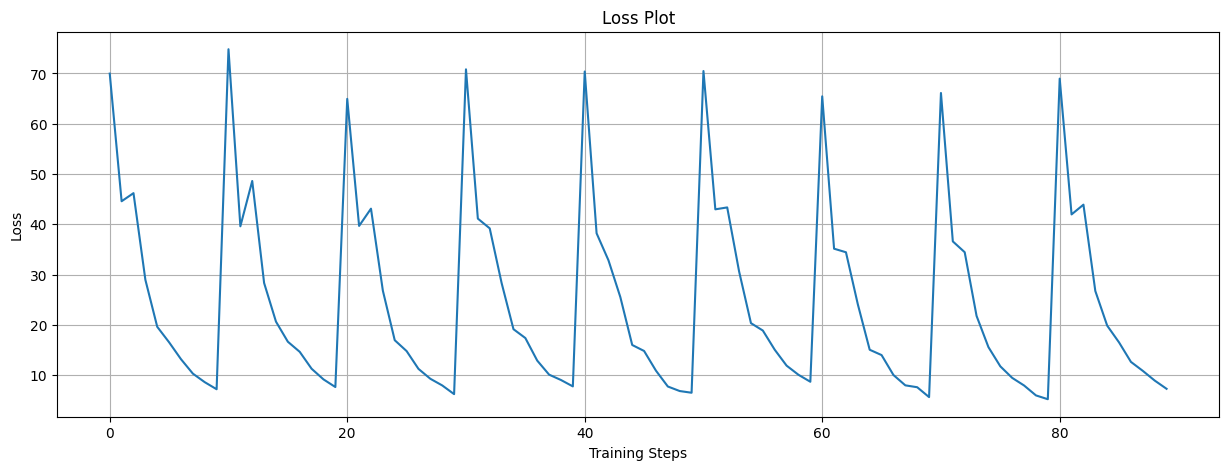

In [57]:
with mlflow.start_run(experiment_id=EXPERIMENT_ID) as run:

    # Constants
    print(f"Model name: {MODEL_NAME}")
    RUN_ID = run.info.run_id
    print(f"Run id: {RUN_ID}")
    EXPERIMENT_ID = run.info.experiment_id
    print(f"Experiment id: {EXPERIMENT_ID}")

    # Training
    print("Starting training...")
    start = time.time()
    ner_model = ner_training_pipeline.fit(training_data)
    end = time.time()
    ELAPSED_SEC_TRAINING = end - start
    print("- Finished!")

    # Saving the model
    print("Saving the model...")
    ner_model.stages[-1].write().overwrite().save(f"{OUTPUT_DIR}/{MODEL_DIR}/{MODEL_NAME}")
    print("- Finished!")

    # Loading the model
    print("Loading back the model...")
    loaded_ner_model = NerDLModel.load(f"{OUTPUT_DIR}/{MODEL_DIR}/{MODEL_NAME}")\
        .setInputCols(["sentence", "token", "embeddings"])\
        .setOutputCol("ner")

    ner_prediction_pipeline = Pipeline(stages = ner_preprocessing_pipeline.getStages() + [loaded_ner_model])

    # Inference
    print("Starting inference...")
    prediction_data = spark.createDataFrame([[""]]).toDF("text")
    prediction_model = ner_prediction_pipeline.fit(prediction_data)
    start = time.time()
    prediction_model.transform(test_data).write.mode('overwrite').parquet(f"{OUTPUT_DIR}/{INFERENCE_NAME}")
    end = time.time()
    ELAPSED_SEC_INFERENCE = end - start
    print("- Finished!")

    # Metrics
    print("Starting metric calculation...")
    predictions = spark.read.parquet(f"{OUTPUT_DIR}/{INFERENCE_NAME}")
    preds_df = predictions.select(
        F.explode(
            F.arrays_zip(
                F.col('token.result').alias('token_res'),
                F.col('label.result').alias('label_res'),
                F.col('ner.result').alias('ner_res')
            )
        ).alias("cols")
    ) \
    .select(
        F.col("cols.token_res").alias("token"),
        F.col("cols.label_res").alias("ground_truth"),
        F.col("cols.ner_res").alias("prediction")
    ).toPandas()
    preds_df = preds_df.fillna(value='O')
    with open(f'{OUTPUT_DIR}/{CLASSIFICATION_REPORT_LOG_NAME}', 'w') as f:
        metrics = classification_report(preds_df['ground_truth'], preds_df['prediction'])
        f.write(metrics)

    metrics_dict = classification_report(preds_df['ground_truth'], preds_df['prediction'], output_dict=True)
    print("- Finished!")

    # Stdout
    print(f"Training dataset size: {TRAINING_SIZE}")
    print(f"Training time (sec): {ELAPSED_SEC_TRAINING}")
    print(f"Inference dataset size: {TEST_SIZE}")
    print(f"Inference time (sec): {ELAPSED_SEC_INFERENCE}")
    print(f"Metrics:\n")
    print(metrics)

    # MLFLow Experiment
    print("Logging params, artifacts, metrics and charts in MLFlow")
    mlflow.log_param("training_size", TRAINING_SIZE)
    mlflow.log_param("training_time", ELAPSED_SEC_TRAINING)
    mlflow.log_param("model_name", MODEL_NAME)
    mlflow.log_param("test_size", TEST_SIZE)
    mlflow.log_param("test_time", ELAPSED_SEC_INFERENCE)
    mlflow.log_param("run_id", RUN_ID)
    mlflow.log_param("experiment_id", EXPERIMENT_ID)
    import importlib
    importlib.reload(ner_image_log_parser) # Reload the module to use the updated version
    for file in glob.glob(f"{OUTPUT_DIR}/*.log"):
        images = {}
        images.update(ner_image_log_parser.get_charts(file, img_prec_rec_f1_path=f"{OUTPUT_DIR}/{PREC_REC_F1_NAME}",
                                  img_macro_micro_avg_path=f"{OUTPUT_DIR}/{MACRO_MICRO_AVG_NAME}"))
        images.update(ner_image_log_parser.loss_plot(file, img_loss_path=f"{OUTPUT_DIR}/{LOSS_NAME}"))

    mlflow.log_artifacts(OUTPUT_DIR)
    mlflow.log_artifact(TRAIN_DATASET)
    mlflow.log_artifact(TEST_DATASET)

    for k,v in metrics_dict.items():
        if isinstance(v, dict):
            for kv, vv in v.items():
                mlflow.log_metric(f"{k}_{kv}", vv)
        else:
            mlflow.log_metric(k, v)
    print("- Finished!")

    print("Logging the model in MLFlow")
    # Logging the model to be explored in the MLFLow UI
    tracking_url_type_store = urlparse(mlflow.get_tracking_uri()).scheme
    # Model registry does not work with file store
    if tracking_url_type_store != "file":

        # Register the model
        # There are other ways to use the Model Registry, which depends on the use case,
        # please refer to the doc for more information:
        # https://mlflow.org/docs/latest/model-registry.html#api-workflow
        mlflow.spark.log_model(ner_model, f"{MODEL_NAME}_{EXPERIMENT_ID}_{RUN_ID}", registered_model_name=MODEL_NAME, pip_requirements=PIP_REQUIREMENTS)
    else:
        mlflow.spark.log_model(ner_model, f"{MODEL_NAME}_{EXPERIMENT_ID}_{RUN_ID}", pip_requirements=PIP_REQUIREMENTS)
    print("- Finished!")

    # Saving the model
    print("Saving the model...")
    input_example = predictions.select("sentence", "token", "embeddings").limit(1).toPandas()
    mlflow.spark.save_model(loaded_ner_model, MODEL_NAME, pip_requirements=PIP_REQUIREMENTS, input_example=input_example)
    print("- Finished!")

# Finally, launch the UI!